In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Fishers maket.csv


### Fish Data Description 🐟

The `fish_data` dataset contains information about various fish species, with several numerical features associated with each fish. 

### Columns:
1. **Species** 🐠: Represents the species of the fish, including categories such as Bream, Roach, Whitefish, Parkki, Perch, Pike, and Smelt.

2. **Weight** ⚖️: Indicates the weight of the fish (unit: grams).

3. **Length1** 📏: Represents one measure of the fish's length.

4. **Length2** 📏: Represents another measure of the fish's length.

5. **Length3** 📏: Represents a third measure of the fish's length.

6. **Height** 📐: Indicates the height of the fish.

7. **Width** 📐: Represents the width of the fish.

### Dataset Overview:
The dataset captures various physical characteristics of different fish species, making it suitable for analysis and modeling, especially in the context of fisheries or ecological studies. The numerical features (Weight, Length1, Length2, Length3, Height, Width) provide quantitative information about the size and dimensions of the fish, while the Species column categorizes the fish into different species.

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #6F4C5B; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h2 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Imports and Setup</h2>
</div>

In [3]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

## <span style="color:transparent;">Load and Explore Dataset</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #6F4C5B; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h2 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Load and Explore Dataset</h2>
</div>

In [4]:
fish_data = pd.read_csv('/kaggle/input/Fishers maket.csv') 
# Display the first few rows of the fish_data
fish_data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [5]:
# Display the last few rows of the fish_data
fish_data.tail()

,Species,Weight,Length1,Length2,Length3,Height,Width
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,13.8,15.0,16.2,2.9322,1.8792


In [6]:
# Check the shape of the fish_data
fish_data.shape

(159, 7)

In [7]:
# Display summary information about the fish_data
fish_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [8]:
# Check for missing values in the fish_data
fish_data.isnull().sum() 

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [9]:
# Check for duplicate values in fish_data
fish_data.duplicated().sum()

0

In [10]:
# Identifying numerical and non-numerical columns in the dataset

# Numerical columns
numerical_columns = fish_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Non-numerical columns
non_numerical_columns = fish_data.select_dtypes(include=['object']).columns.tolist()

# Display the numerical and non-numerical columns
print("Categorical Columns:", non_numerical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: ['Species']
Numerical Columns: ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


In [11]:
# Unique values in the 'Species' column
fish_data['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [12]:
# Value counts for 'Species'
fish_data.Species.value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

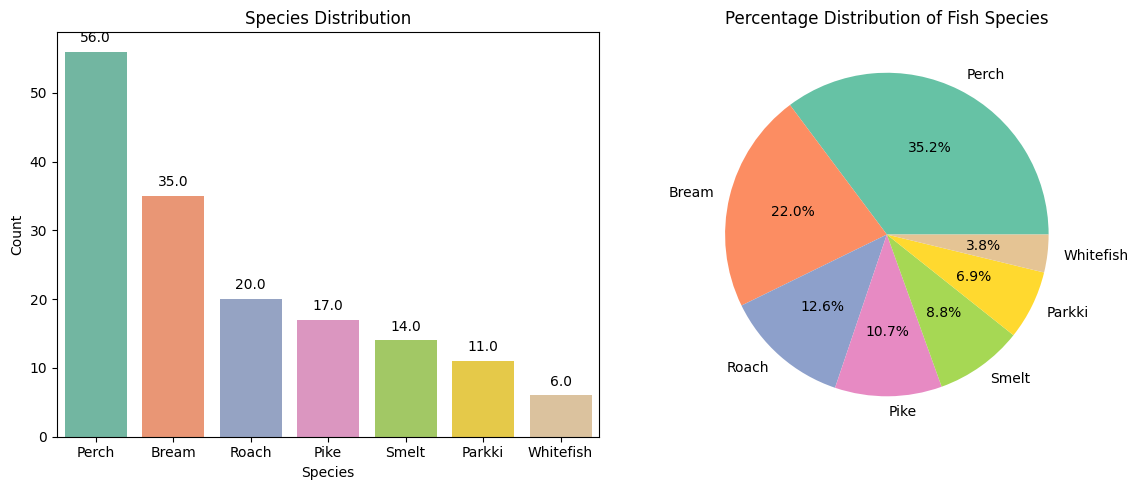

In [13]:
# Set up the subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Bar chart for species distribution
species_counts = fish_data['Species'].value_counts()
sns.barplot(x=species_counts.index, y=species_counts, ax=axes[0], palette='Set2')
axes[0].set_title('Species Distribution')
axes[0].set_ylabel('Count')

# Add total count labels on top of the bar
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Pie chart for percentage distribution of Fish Species
species_percentage = fish_data['Species'].value_counts(normalize=True) * 100
axes[1].pie(species_percentage, labels=species_percentage.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Percentage Distribution of Fish Species')

# Display the plot
plt.tight_layout()
plt.show()

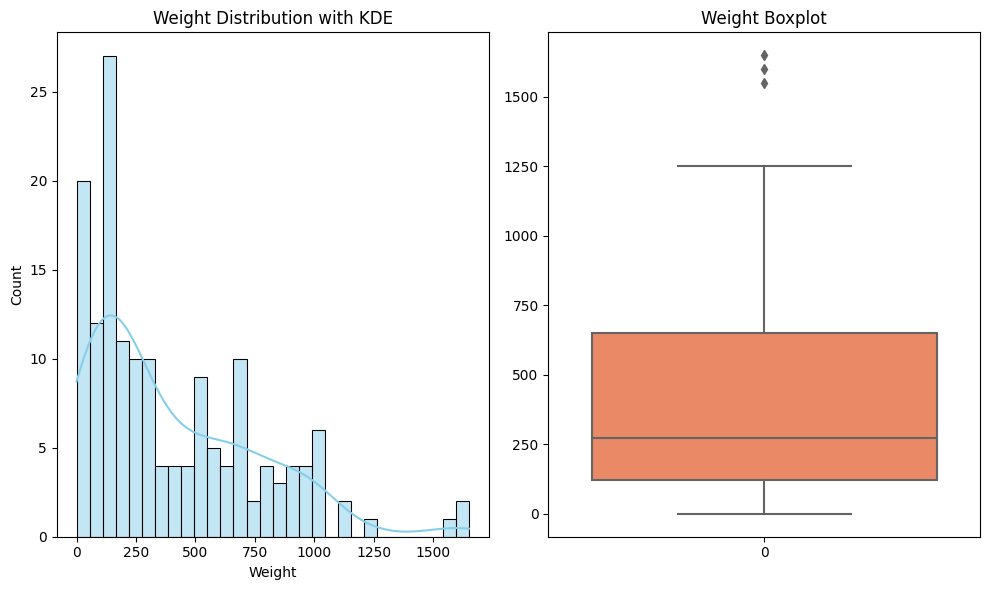


Summary Statistics for Weight:
 count     159.000000
mean      398.326415
std       357.978317
min         0.000000
25%       120.000000
50%       273.000000
75%       650.000000
max      1650.000000
Name: Weight, dtype: float64


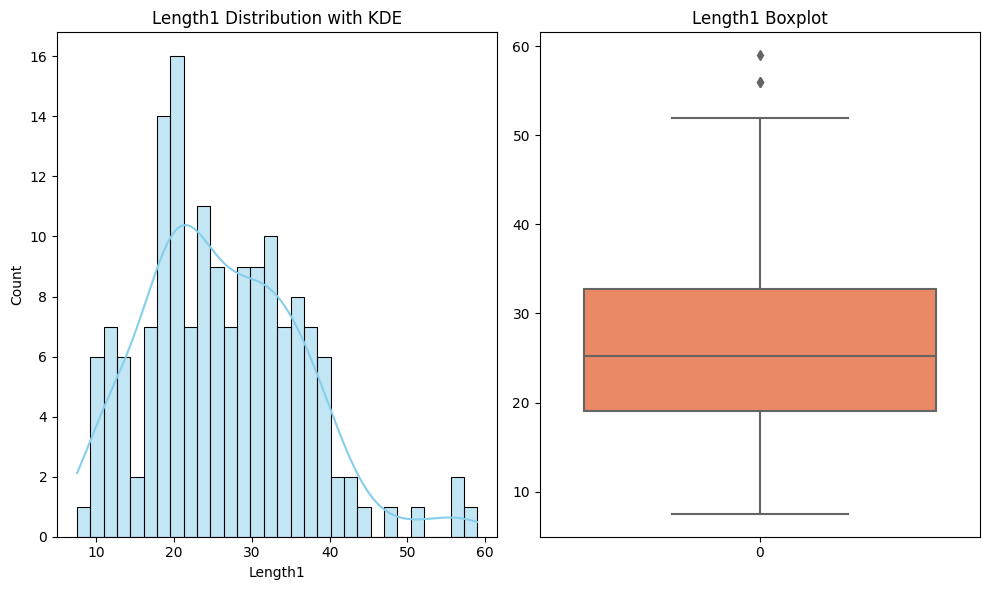


Summary Statistics for Length1:
 count    159.000000
mean      26.247170
std        9.996441
min        7.500000
25%       19.050000
50%       25.200000
75%       32.700000
max       59.000000
Name: Length1, dtype: float64


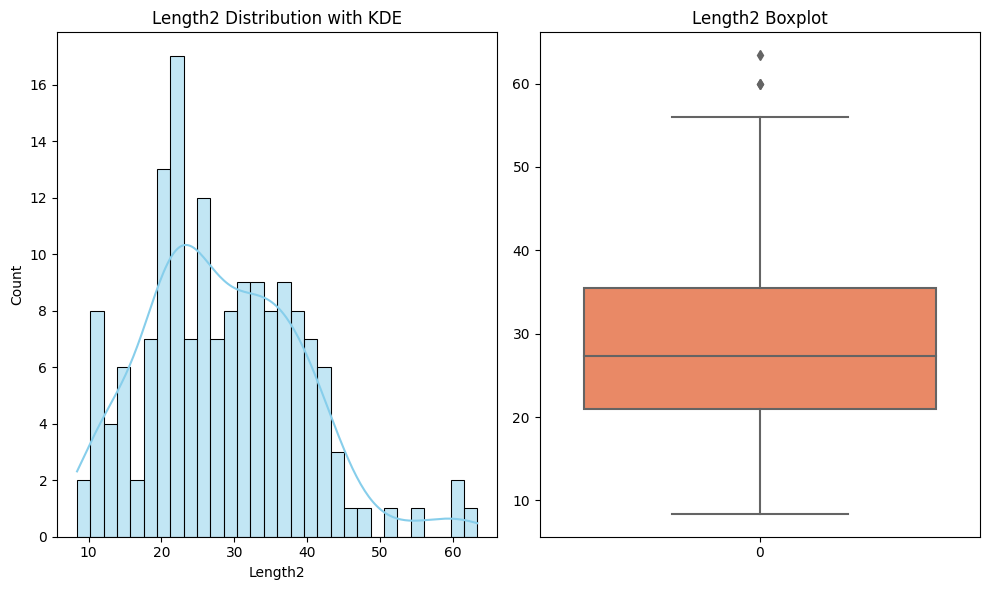


Summary Statistics for Length2:
 count    159.000000
mean      28.415723
std       10.716328
min        8.400000
25%       21.000000
50%       27.300000
75%       35.500000
max       63.400000
Name: Length2, dtype: float64


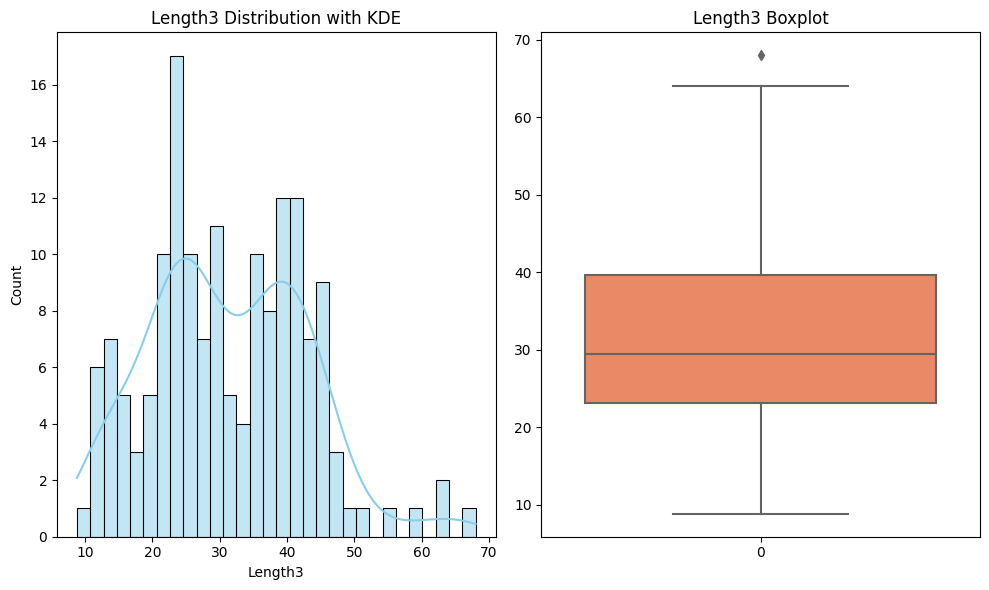


Summary Statistics for Length3:
 count    159.000000
mean      31.227044
std       11.610246
min        8.800000
25%       23.150000
50%       29.400000
75%       39.650000
max       68.000000
Name: Length3, dtype: float64


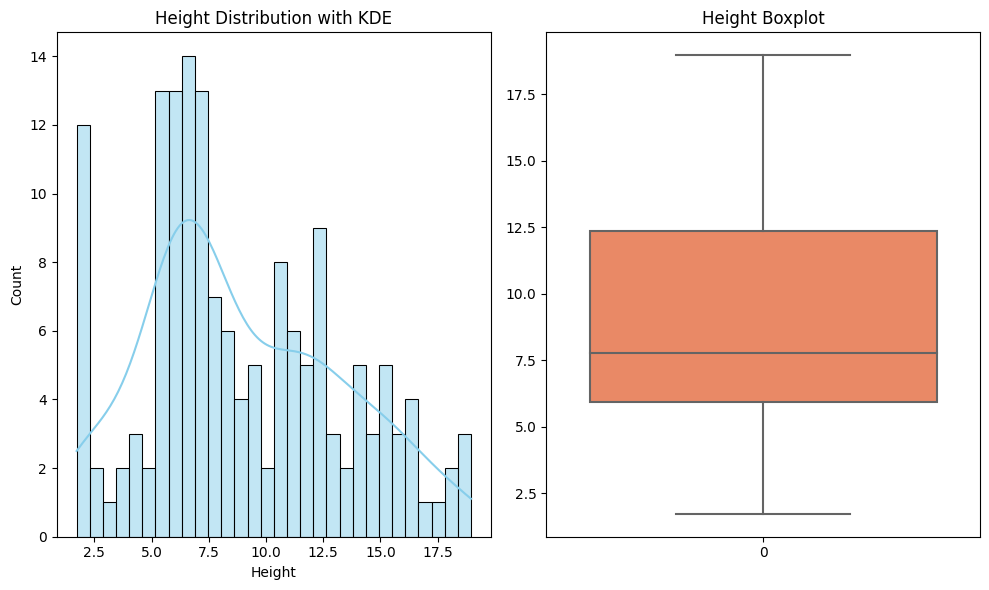


Summary Statistics for Height:
 count    159.000000
mean       8.970994
std        4.286208
min        1.728400
25%        5.944800
50%        7.786000
75%       12.365900
max       18.957000
Name: Height, dtype: float64


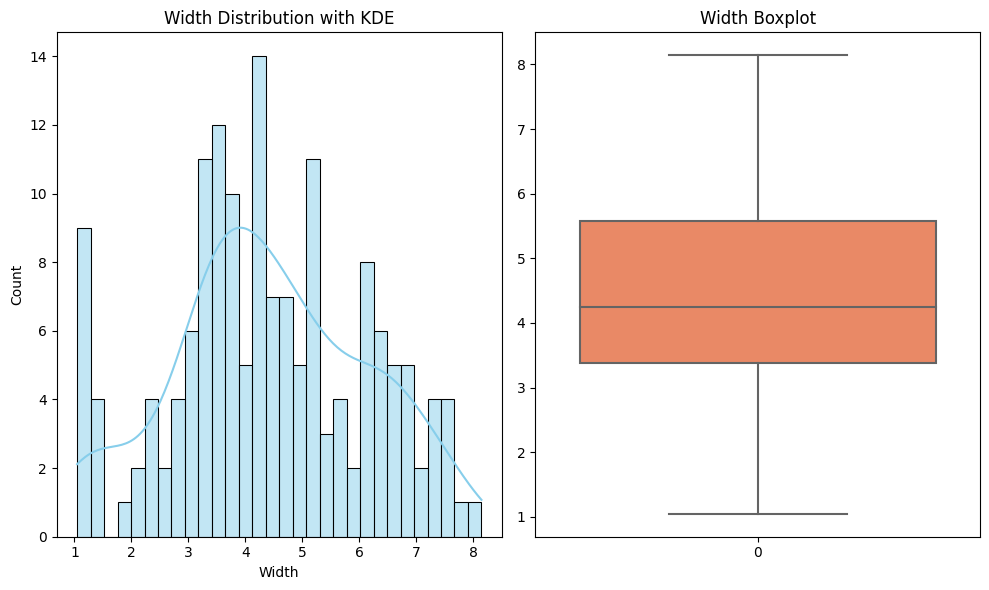


Summary Statistics for Width:
 count    159.000000
mean       4.417486
std        1.685804
min        1.047600
25%        3.385650
50%        4.248500
75%        5.584500
max        8.142000
Name: Width, dtype: float64


In [14]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, column, title):
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(data[column], kde=True, bins=30, color='skyblue')
    plt.title(f'{title} Distribution with KDE')

    plt.subplot(1, 2, 2)
    sns.boxplot(data[column], color='coral')
    plt.title(f'{title} Boxplot')

    plt.tight_layout()
    plt.show()

    print(f'\nSummary Statistics for {title}:\n', data[column].describe())

columns_to_analyze = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

for column in columns_to_analyze:
    univariate_analysis(fish_data, column, column.replace('_', ' '))

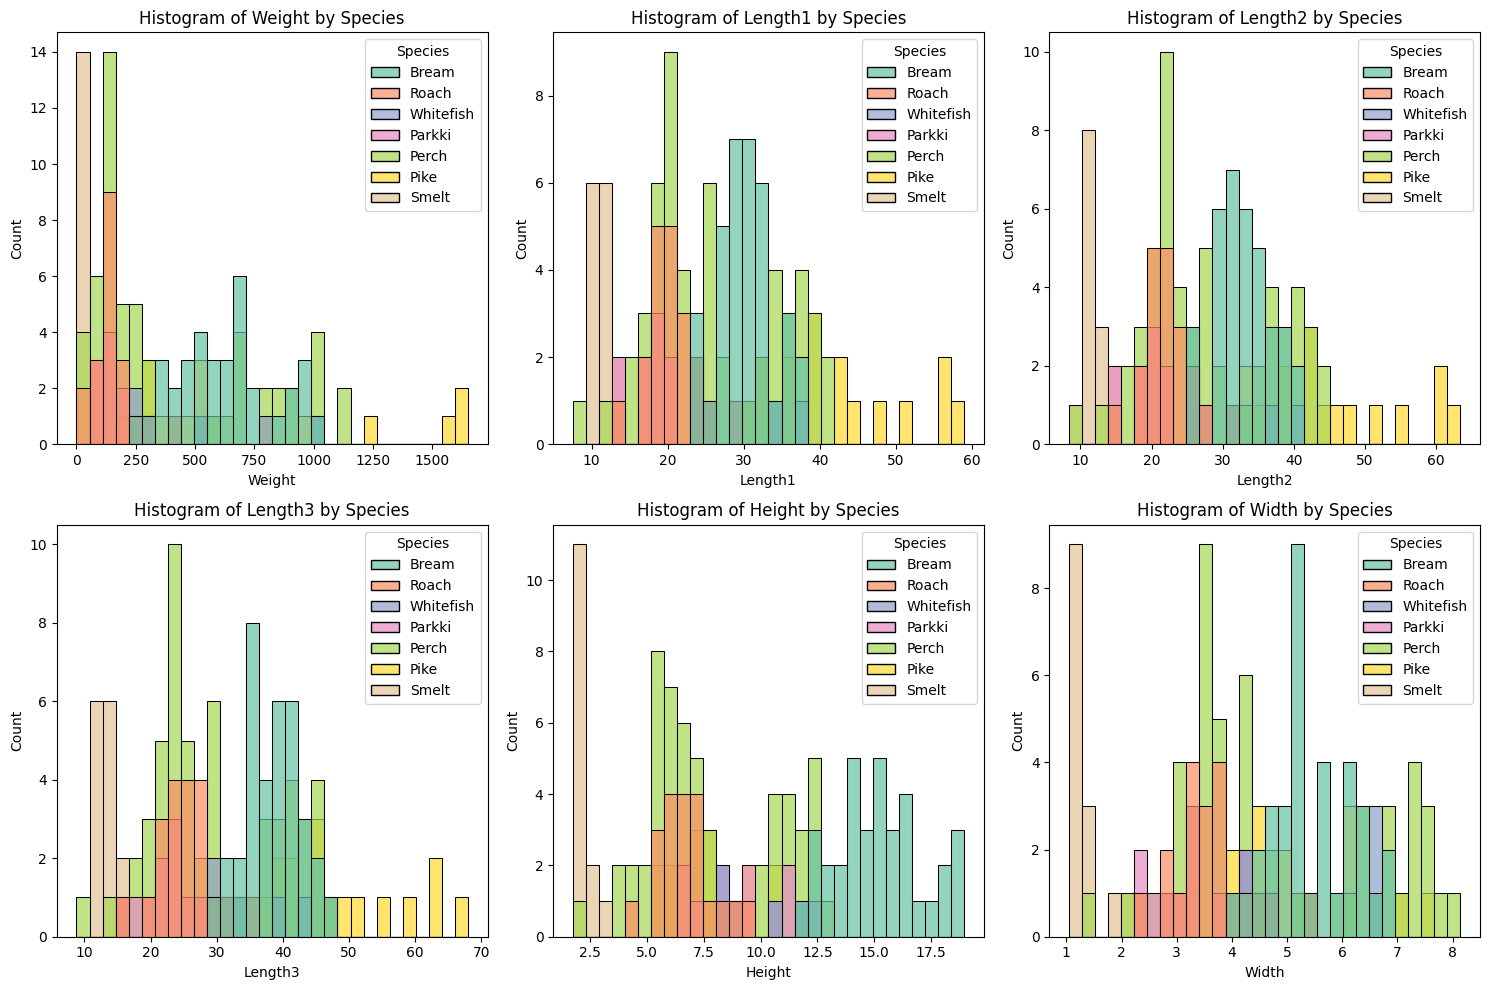

In [15]:
# Create histograms by species for each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_to_analyze, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=fish_data, x=column, hue='Species', bins=30, palette='Set2', alpha=0.7)
    plt.title(f'Histogram of {column} by Species')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

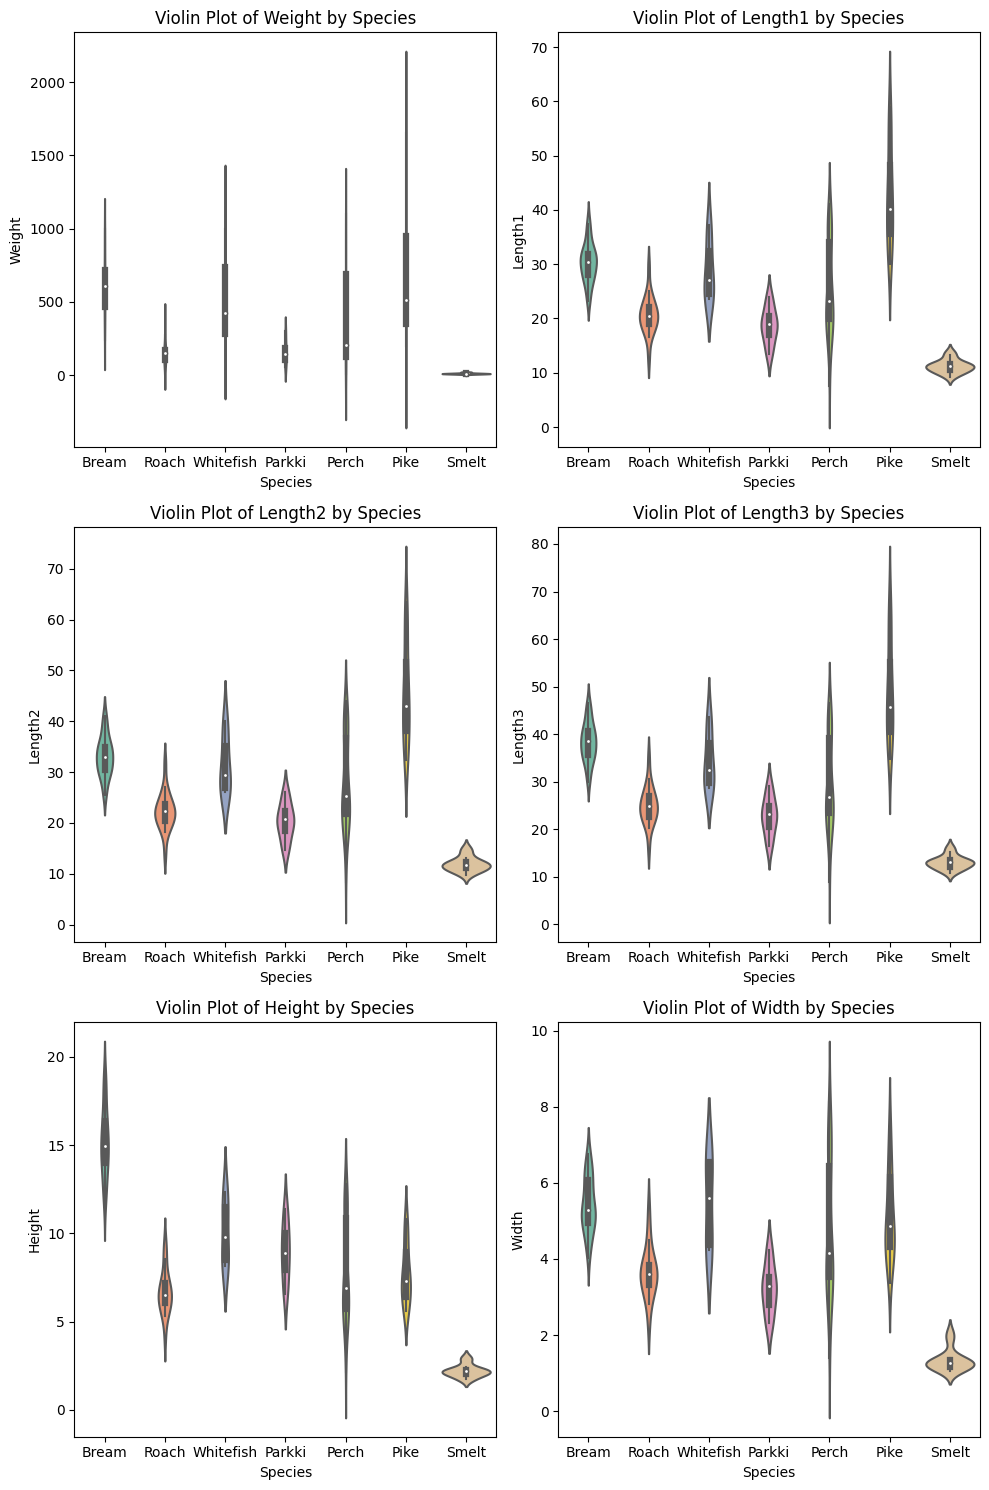

In [16]:
# Create violin plots by species for each feature
plt.figure(figsize=(10, 15))
for i, column in enumerate(columns_to_analyze, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(data=fish_data, x='Species', y=column, palette='Set2')
    plt.title(f'Violin Plot of {column} by Species')
    plt.xlabel('Species')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

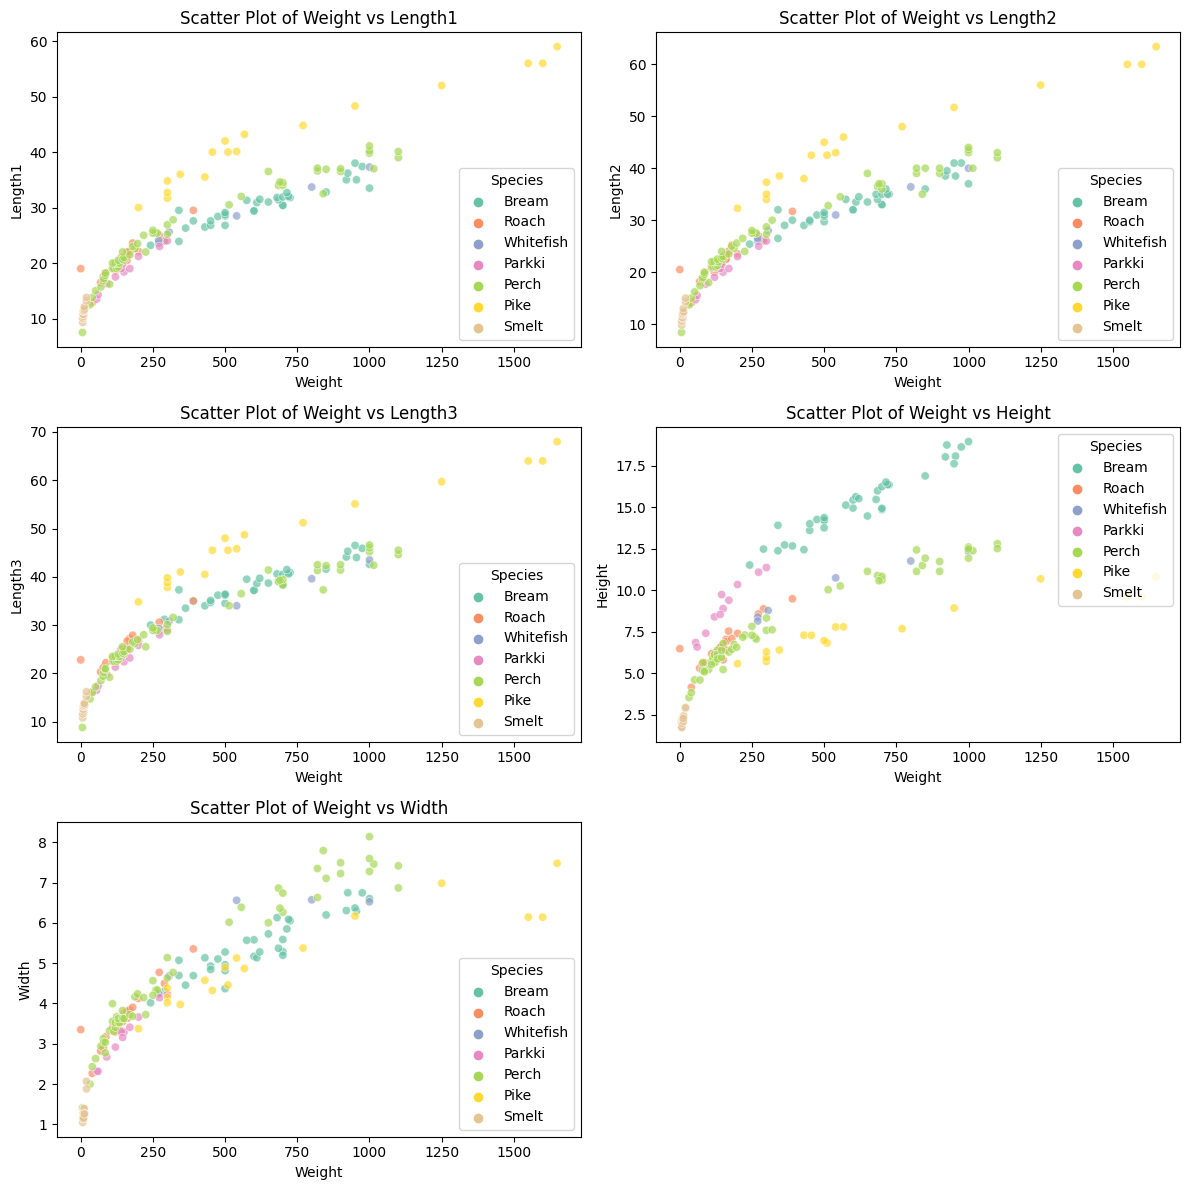

In [17]:
# Columns to analyze for scatter plot with 'Weight' and 'Species'
columns_to_analyze = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

# Create scatter plots with 'Weight', other columns, and color-coded by 'Species'
plt.figure(figsize=(12, 12))
for i, column in enumerate(columns_to_analyze, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(data=fish_data, x='Weight', y=column, hue='Species', palette='Set2', alpha=0.7)
    plt.title(f'Scatter Plot of Weight vs {column}')
    plt.xlabel('Weight')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

In [18]:
# Identify rows where the weight is less than or equal to zero
fish_data[fish_data.Weight <= 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


- This step aims to identify and examine rows where the weight of the fish is less than or equal to zero. A weight value less than or equal to zero is likely invalid or represents a missing or erroneous data point. By inspecting these rows, can gain an understanding of the data quality issues related to weight values.

In [19]:
# Drop the identified row(s)
fish_data = fish_data.drop([40])

This step removes the identified row(s) from the `fish_data` DataFrame. 
- In this specific case, it removes the row with index 40, which was identified in the previous step as having a weight less than or equal to zero. 
- Removing rows with invalid or nonsensical data helps to ensure the integrity of the dataset for further analysis. 

In [20]:
# Print the new dimension of the dataset
print('New dimension of the dataset = ', fish_data.shape)

New dimension of the dataset =  (158, 7)


In [21]:
# Subset the selected columns
selected_columns = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']
subset_data = fish_data[selected_columns]
# Correlation
subset_data.corr()

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915719,0.918603,0.923090,0.723857,0.886654
Length1,0.915719,1.000000,0.999516,0.992004,0.624409,0.866684
Length2,0.918603,0.999516,1.000000,0.994083,0.639503,0.873201
Length3,0.923090,0.992004,0.994083,1.000000,0.702655,0.878189
Height,0.723857,0.624409,0.639503,0.702655,1.000000,0.792401
Width,0.886654,0.866684,0.873201,0.878189,0.792401,1.000000


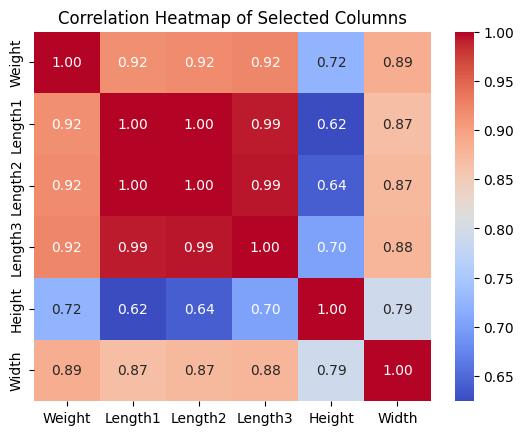

In [22]:
# Correlation heatmap
correlation_matrix = subset_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Columns')
plt.show()

***Based on the correlation matrix:***

1. **Weight vs. Length Measurements:**
    There is a very strong positive correlation between 'Weight' and each of the length measurements ('Length1', 'Length2', 'Length3'). Correlation coefficients ranging from approximately 0.916 to 0.923 indicate a high degree of positive linear relationship. This suggests that as the length of the fish increases, its weight tends to increase proportionally.

2. **Length1, Length2, and Length3:**
    'Length1', 'Length2', and 'Length3' exhibit extremely high positive correlations with each other (correlation coefficients close to 1). This indicates that these length measurements are almost perfectly correlated, which is expected as they represent different dimensions of the same characteristic (length) of the fish.

3. **Height vs. Weight:**
    There is a moderately strong positive correlation (approximately 0.724) between 'Height' and 'Weight'. This suggests that, on average, as the height of the fish increases, its weight tends to increase as well.

4. **Width vs. Other Measurements:**
'Width' shows strong positive correlations with all length measurements ('Length1', 'Length2', 'Length3'). This indicates that as the length and width of the fish increase, there is a positive relationship with each other.


5. **Height vs. Width:**
    There is a strong positive correlation (approximately 0.792) between 'Height' and 'Width'. This suggests that, on average, as the height of the fish increases, its width tends to increase as well.

6. **Interpretation of Correlation Coefficients:**
    The correlation coefficients range from -1 to 1, where 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation. In this case, the positive values suggest a positive linear relationship, while the closer the value is to 1 or -1, the stronger the correlation.


***A correlation close to 1 between 'Length1', and 'Length2' indicates a very high degree of linear dependence or multicollinearity. Multicollinearity occurs when two or more independent variables in a regression model are highly correlated, making it difficult to isolate the individual effects of each variable on the dependent variable.***

In [23]:
#Drop columns 'Length2'
fish_data = fish_data.drop('Length2', axis=1)

**Justification:**

- By dropping the highly correlated columns 'Length2', address the issue of multicollinearity. 
- This step can be beneficial for improving the stability and interpretability of regression models and reducing the risk of unreliable coefficient estimates.

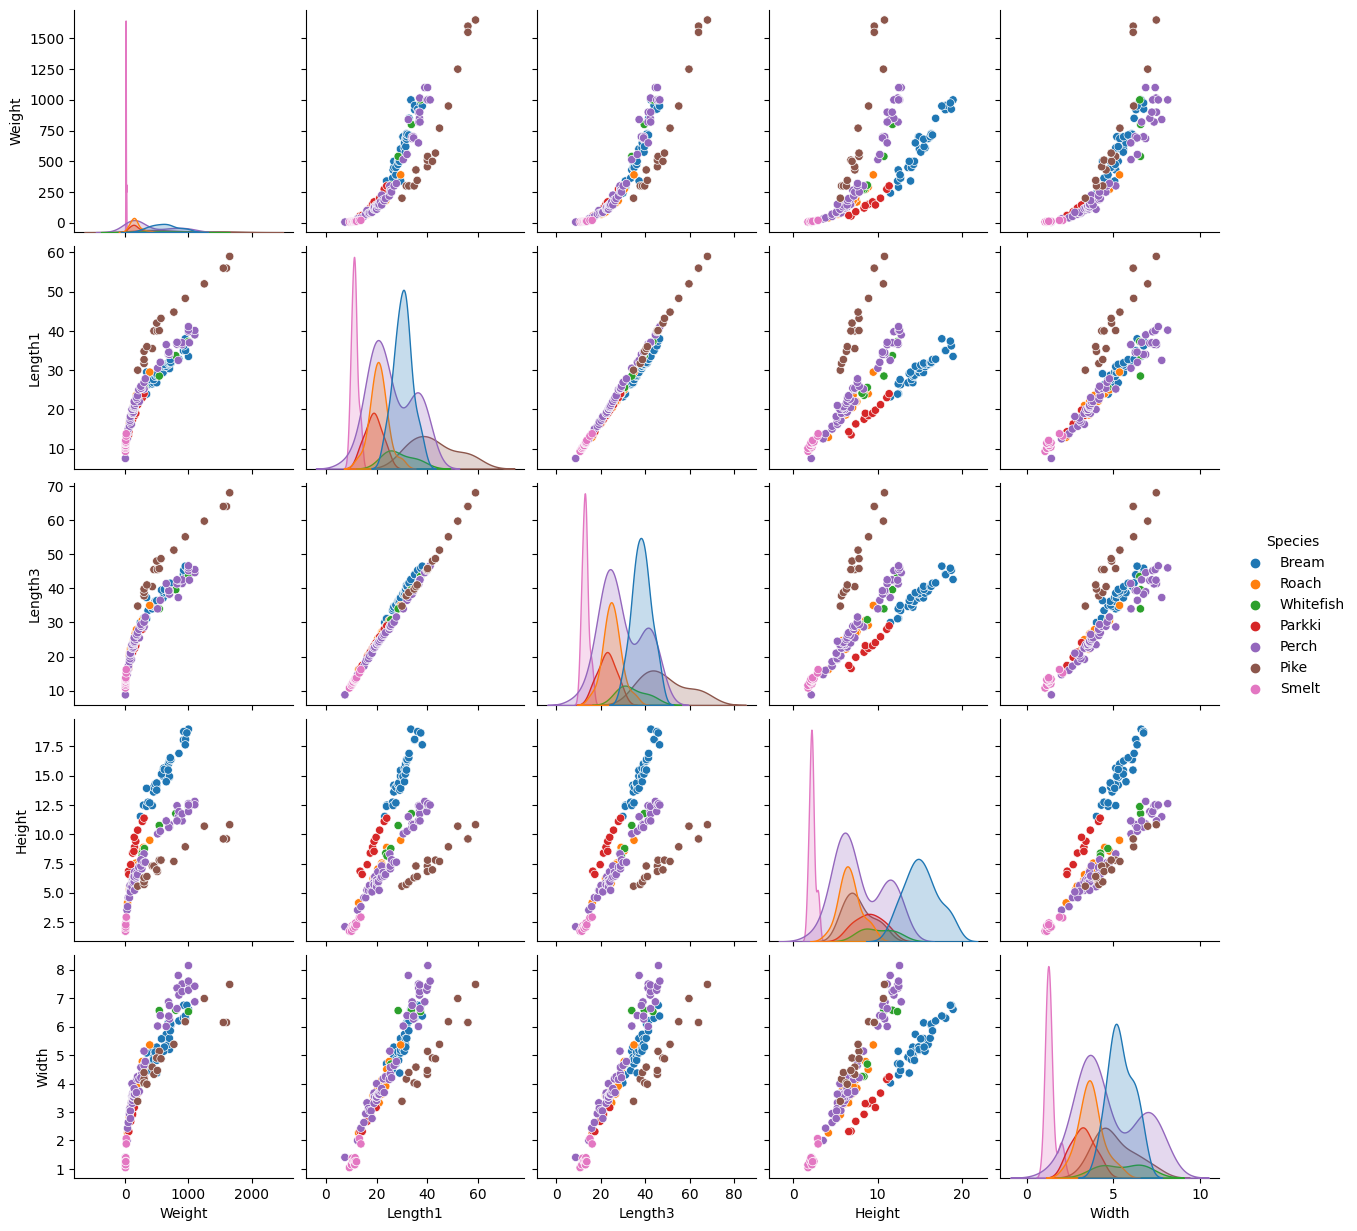

In [24]:
# Create a scatterplot matrix with different species colored
sns.pairplot(fish_data, kind = 'scatter', hue = 'Species')

**Explanation:**

1. **Correlation Between 'Height', 'Width', and 'Weight':**
    The pair plot suggests that there might be correlations between the variables 'Height', 'Width', and 'Weight' across multiple fish species. Specifically, as the 'Height' and 'Width' values vary, there seems to be a corresponding variation in 'Weight'. This observation aligns with the correlation matrix you previously examined.
    
2. **Species-Specific Correlations:**
    It's important to note that while there are apparent correlations, the relationships between 'Height', 'Width', and 'Weight' may not be exactly linear for each individual fish species. The scatterplots for each species show variations in the relationships, and the correlations might differ for different species.

3. **Interpreting Scatterplots:**
    In the off-diagonal scatterplots, each point represents an individual fish, and the color indicates its species. Clusters or patterns within these scatterplots can provide insights into how different species behave in terms of 'Height', 'Width', and 'Weight'

In [25]:
# Selecting only numerical columns for simplicity
numerical_columns = fish_data.select_dtypes(include=['float64', 'int64']).columns

# Function to detect outliers using IQR
def detect_outliers(data):
    outliers = {}
    for column in data.columns:
        if column in numerical_columns:
            # Calculate the IQR for the column
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1

            # Identify outliers using the IQR
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Check for outliers and store the result in the dictionary
            outliers[column] = data[(data[column] < lower_bound) | (data[column] > upper_bound)].index.tolist()

    return outliers

# Detect outliers in the fish_data DataFrame
outliers_dict = detect_outliers(fish_data)

In [26]:
# Display columns with outliers
columns_with_outliers = [column for column, indices in outliers_dict.items() if len(indices) > 0]

if len(columns_with_outliers) == 0:
    print("No columns have outliers.")
else:
    print(f"Columns with outliers: {', '.join(columns_with_outliers)}")

Columns with outliers: Weight, Length1, Length3


In [27]:
# Display rows with outliers in the 'Weight' column
outliers_indices = outliers_dict.get('Weight', [])

if len(outliers_indices) == 0:
    print("No outliers found in the 'Weight' column.")
else:
    print(f"Indices of outliers in the 'Weight' column: {', '.join(map(str, outliers_indices))}")

# Print the actual values of the 'Weight' column for the outliers
outliers_weight_values = fish_data.loc[outliers_indices, 'Weight']

if not outliers_weight_values.empty:
    print(f"Values of outliers in the 'Weight' column:\n{outliers_weight_values}")

Indices of outliers in the 'Weight' column: 142, 143, 144
Values of outliers in the 'Weight' column:
142    1600.0
143    1550.0
144    1650.0
Name: Weight, dtype: float64


In [28]:
# Display rows with outliers in the 'Length1', 'Length2', 'Length3' columns
for column in ['Length1', 'Length3']:
    outliers_indices = outliers_dict.get(column, [])
    if len(outliers_indices) == 0:
        print(f"No outliers found in the '{column}' column.")
    else:
        print(f"Indices of outliers in the '{column}' column: {', '.join(map(str, outliers_indices))}")

    # Print the actual values of the 'Length' column for the outliers
    outliers_length_values = fish_data.loc[outliers_indices, column]

    if not outliers_length_values.empty:
        print(f"Values of outliers in the '{column}' column:\n{outliers_length_values}")

Indices of outliers in the 'Length1' column: 142, 143, 144
Values of outliers in the 'Length1' column:
142    56.0
143    56.0
144    59.0
Name: Length1, dtype: float64
Indices of outliers in the 'Length3' column: 144
Values of outliers in the 'Length3' column:
144    68.0
Name: Length3, dtype: float64


In [29]:
fish_data[141:144]

,Species,Weight,Length1,Length3,Height,Width
142,Pike,1600.0,56.0,64.0,9.600,6.144
143,Pike,1550.0,56.0,64.0,9.600,6.144
144,Pike,1650.0,59.0,68.0,10.812,7.480


In [30]:
# Remove rows with indices 142, 143, and 144
fish_data = fish_data.drop([142, 143, 144])

# Print the new dimensions of the DataFrame
print(fish_data.shape)

(155, 6)


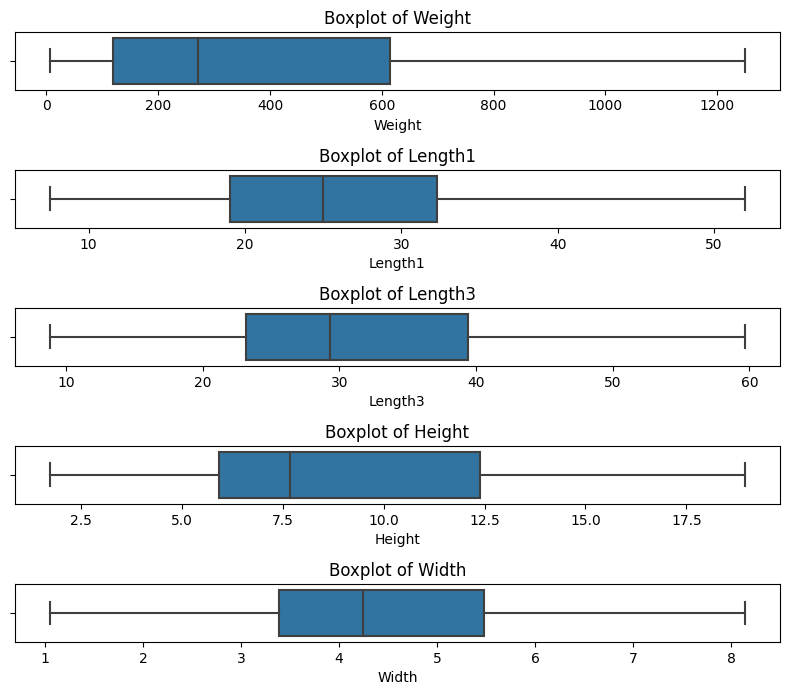

In [31]:
# Columns to analyze for outliers
columns_to_analyze = ['Weight', 'Length1', 'Length3', 'Height', 'Width']

# Create box plots to visualize potential outliers
plt.figure(figsize=(8, 8))
for i, column in enumerate(columns_to_analyze, 1):
    plt.subplot(6, 1, i)
    sns.boxplot(x=column, data=fish_data)
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [32]:
# Display descriptive statistics for the columns
fish_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,155.0,377.638065,319.144511,5.9000,120.00000,272.0000,615.00000,1250.000
Length1,155.0,25.698710,9.133355,7.5000,19.05000,25.0000,32.25000,52.000
Length3,155.0,30.621290,10.711621,8.8000,23.15000,29.3000,39.45000,59.700
Height,155.0,8.967102,4.333722,1.7284,5.92695,7.6800,12.37930,18.957
Width,155.0,4.382326,1.675564,1.0476,3.38565,4.2476,5.47275,8.142


In [33]:
# Display unique values in the 'Species' column before mapping
fish_data['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [34]:
# Assuming 'Species' is a categorical column in your DataFrame
le = LabelEncoder()

# Fit and transform the 'Species' column
fish_data['Species'] = le.fit_transform(fish_data['Species'])

In [35]:
le.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [36]:
# Display unique values in the 'Species' column after mapping
fish_data['Species'].unique()

array([0, 4, 6, 1, 2, 3, 5])

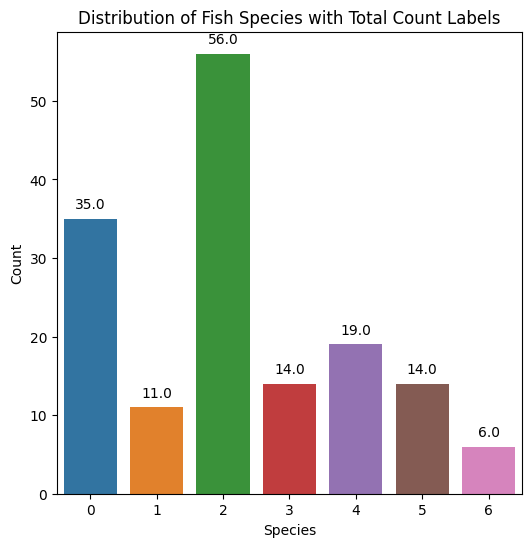

In [37]:
# Bar chart for species distribution with total count labels
plt.figure(figsize=(6, 6))
ax = sns.countplot(x='Species', data=fish_data)

# Add total count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribution of Fish Species with Total Count Labels')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


## <span style="color:transparent;">Modeling</span>

<div style="border-radius: 15px 0 15px 0px; border: 2px solid #f1c40f; padding: 10px; background-color: #6F4C5B; text-align: center; box-shadow: 0px 2px 4px rgba(0, 0, 0, 0.2);">
    <h2 style="color: #f1c40f; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 24px;">Modeling</h2>
</div>

In [38]:
# Splitting the data
x_train, x_test, y_train, y_test = train_test_split(fish_data.drop(['Weight'], axis=1), fish_data['Weight'], test_size=0.2, random_state=123)


In [39]:
# Defining models
model_LR = LinearRegression()
model_DT = DecisionTreeRegressor()
model_RF = RandomForestRegressor()
model_XGB = xgboost.XGBRegressor()

In [40]:
x_train

,Species,Length1,Length3,Height,Width
151,5,11.3,13.1,2.2139,1.2838
126,2,40.2,46.0,12.6040,8.1420
4,0,26.5,34.0,12.4440,5.1340
139,3,44.8,51.2,7.6800,5.3760
46,4,21.0,25.0,6.5500,3.3250
...,...,...,...,...,...
17,0,30.4,38.5,14.9380,5.1975
99,2,23.0,26.5,6.4395,3.6835
67,1,19.0,23.2,9.3960,3.4104
127,2,41.1,46.6,12.4888,7.5958


In [41]:
# Fitting models
model_LR.fit(x_train, y_train)
model_DT.fit(x_train, y_train)
model_RF.fit(x_train, y_train)
model_XGB.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [43]:
import joblib

joblib.dump(model_XGB, "xgboost_model.joblib")
joblib.dump(model_RF, "random.joblib")

['random.joblib']

In [ ]:
# Making predictions
predictions_LR = model_LR.predict(x_test)
predictions_DT = model_DT.predict(x_test)
predictions_RF = model_RF.predict(x_test)
predictions_XGB = model_XGB.predict(x_test)

In [ ]:
# Scoring the models
print("Model Scores:")
print("Linear Regression:", model_LR.score(x_test, y_test))
print("Decision Tree Regressor:", model_DT.score(x_test, y_test))
print("Random Forest Regressor:", model_RF.score(x_test, y_test))
print("XGBoost Regressor:", model_XGB.score(x_test, y_test))

In [ ]:
# Calculate Mean Absolute Error (MAE)
mae_LR = mean_absolute_error(y_test, predictions_LR)
mae_DT = mean_absolute_error(y_test, predictions_DT)
mae_RF = mean_absolute_error(y_test, predictions_RF)
mae_XGB = mean_absolute_error(y_test, predictions_XGB)

In [ ]:
# Calculate Mean Squared Error (MSE)
mse_LR = mean_squared_error(y_test, predictions_LR)
mse_DT = mean_squared_error(y_test, predictions_DT)
mse_RF = mean_squared_error(y_test, predictions_RF)
mse_XGB = mean_squared_error(y_test, predictions_XGB)

In [ ]:
# Calculate Root Mean Squared Error (RMSE)
rmse_LR = math.sqrt(mse_LR)
rmse_DT = math.sqrt(mse_DT)
rmse_RF = math.sqrt(mse_RF)
rmse_XGB = math.sqrt(mse_XGB)

In [ ]:
# Calculate R-squared (R2)
r2_LR = r2_score(y_test, predictions_LR)
r2_DT = r2_score(y_test, predictions_DT)
r2_RF = r2_score(y_test, predictions_RF)
r2_XGB = r2_score(y_test, predictions_XGB)

In [ ]:
# Print the results
print("Linear Regression:")
print(f"MAE: {mae_LR}, MSE: {mse_LR}, RMSE: {rmse_LR}, R2: {r2_LR}")

print("\nDecision Tree Regressor:")
print(f"MAE: {mae_DT}, MSE: {mse_DT}, RMSE: {rmse_DT}, R2: {r2_DT}")

print("\nRandom Forest Regressor:")
print(f"MAE: {mae_RF}, MSE: {mse_RF}, RMSE: {rmse_RF}, R2: {r2_RF}")

print("\nXGBoost Regressor:")
print(f"MAE: {mae_XGB}, MSE: {mse_XGB}, RMSE: {rmse_XGB}, R2: {r2_XGB}")

In [ ]:
# Cross-validation scores
cv_scores_LR = cross_val_score(model_LR, x_train, y_train, cv=5, scoring='r2')
cv_scores_DT = cross_val_score(model_DT, x_train, y_train, cv=5, scoring='r2')
cv_scores_RF = cross_val_score(model_RF, x_train, y_train, cv=5, scoring='r2')
cv_scores_XGB = cross_val_score(model_XGB, x_train, y_train, cv=5, scoring='r2')

# Print cross-validation scores for all models
print("\nCross-Validation R2 Scores:")
print("Linear Regression:", cv_scores_LR.mean())
print("Decision Tree Regressor:", cv_scores_DT.mean())
print("Random Forest Regressor:", cv_scores_RF.mean())
print("XGBoost Regressor:", cv_scores_XGB.mean())

In [ ]:
# Calculate residuals
residuals_RF = y_test - predictions_RF
residuals_XGB = y_test - predictions_XGB

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(predictions_RF, residuals_RF, label='Random Forest Residuals')
plt.scatter(predictions_XGB, residuals_XGB, label='XGBoost Residuals', alpha=0.7)
plt.hlines(0, min(predictions_RF), max(predictions_RF), colors='r', linestyles='dashed')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()

In [ ]:
# Get feature importance
feature_importances_RF = model_RF.feature_importances_
sorted_idx_RF = np.argsort(feature_importances_RF)

# Plot feature importance
plt.figure(figsize=(10, 6)) 
plt.barh(range(len(sorted_idx_RF)), feature_importances_RF[sorted_idx_RF], color='skyblue')
plt.yticks(range(len(sorted_idx_RF)), x_train.columns[sorted_idx_RF])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)  
plt.show()

In [ ]:
xgboost.plot_importance(model_XGB)
plt.show()

In [ ]:
# Model ensembling using a simple average of Random Forest and XGBoost predictions
ensemble_predictions = (predictions_RF + predictions_XGB) / 2

# Calculate the ensemble metrics (MAE, MSE, RMSE, R2)
mae_ensemble = mean_absolute_error(y_test, ensemble_predictions)
mse_ensemble = mean_squared_error(y_test, ensemble_predictions)
rmse_ensemble = math.sqrt(mse_ensemble)
r2_ensemble = r2_score(y_test, ensemble_predictions)

# Print ensemble results
print(f"Ensemble Model - MAE: {mae_ensemble}, MSE: {mse_ensemble}, RMSE: {rmse_ensemble}, R2: {r2_ensemble}")


### Model Evaluation Summary:

Based on evaluation, here’s a summary of each model’s performance:

#### **Single Model Results:**
1. **Linear Regression:**
   - MAE: 87.45
   - MSE: 12,611.21
   - RMSE: 112.30
   - R²: 0.8841
   - Cross-Validation R²: 0.9118

2. **Decision Tree Regressor:**
   - MAE: 58.13
   - MSE: 9,518.70
   - RMSE: 97.56
   - R²: 0.9125
   - Cross-Validation R²: 0.9431

3. **Random Forest Regressor:**
   - MAE: 48.18
   - MSE: 6,534.30
   - RMSE: 80.84
   - R²: 0.9399
   - Cross-Validation R²: 0.9734

4. **XGBoost Regressor:**
   - MAE: 45.40
   - MSE: 6,923.58
   - RMSE: 83.21
   - R²: 0.9364
   - Cross-Validation R²: 0.9630

#### **Ensemble Model Results (Average of Random Forest and XGBoost):**
   - MAE: 45.45
   - MSE: 6,546.38
   - RMSE: 80.91
   - R²: 0.9399

### Analysis:

- The **Random Forest Regressor** and **XGBoost Regressor** individually perform quite well, with Random Forest having a slightly better RMSE and R². However, both models show excellent results, with XGBoost having a smaller MAE, suggesting slightly more accurate predictions on average.
  
- The **Ensemble Model** (average of Random Forest and XGBoost predictions) performs comparably to the individual models, with an RMSE and R² very close to the Random Forest. The MAE is very similar to XGBoost, meaning it benefits from both models’ strengths.

### Key Insights:

1. **Random Forest** shows the best overall performance in terms of RMSE and R², which means it might be the best single model for this task.
2. **XGBoost** has slightly better MAE, so its predictions are slightly more accurate on average.
3. **Ensemble Model** combines the strengths of both Random Forest and XGBoost, with balanced metrics. If you're looking for robustness, this ensemble might be a strong choice as it maintains high performance across different metrics.